# F4_Evaluacion.ipynb

**MCDI504 — Machine Learning I**
**Evaluación Formativa 4 — Avance del Proyecto, Fase 4: Evaluación y Validación del Modelo**

**Grupo N.2** — Enzo Pinilla, Claudio Alarcón, Luis Rodrigo Espinoza
**Docente:** David Ruete Zúñiga
**Fecha:** Agosto 2026
**Repositorio del proyecto:** https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2

Este notebook es la evidencia técnica de la Fase 4 y corresponde al archivo `notebooks/F4_Evaluacion.ipynb` del repositorio del proyecto. Las tablas, matrices, figuras y métricas generadas por este notebook constituyen la fuente que deberá utilizarse para actualizar el informe `MCDI504_S4_1_GRUPO2`, asegurando correspondencia entre ambos entregables.

## 1. Propósito de la Formativa 4

El propósito de este avance es evaluar el desempeño de las tres redes neuronales tipo MLP desarrolladas en la Fase 3 del proyecto (una, dos y tres capas ocultas) sobre el conjunto de prueba del dataset Titanic, y aplicar validación cruzada K-Fold estratificada a la red de una capa oculta para analizar la estabilidad de sus métricas.

De acuerdo con el resultado de aprendizaje RA4 y los indicadores ID4.1 e ID4.2, el trabajo se concentra en:

1. Evaluar las tres arquitecturas MLP mediante matriz de confusión, accuracy, precision, recall y F1-score sobre la clase objetivo `sobrevivió = 1`.
2. Aplicar K-Fold estratificado (k=5) a la red de una capa oculta, reportando resultados por partición, promedio y desviación estándar.
3. Interpretar comparativamente ambos protocolos de evaluación (Hold-Out y K-Fold) y formular conclusiones preliminares.

No se realiza ajuste de hiperparámetros, búsqueda de nuevas arquitecturas, balanceo de clases ni cálculo de métricas distintas de las solicitadas: el alcance de esta fase es exclusivamente evaluativo.

In [1]:
# Librerías utilizadas en la evaluación y validación de los modelos
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.exceptions import ConvergenceWarning

# Semilla fija para reproducibilidad de particiones y modelos
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carpeta de figuras del notebook (compatible con ejecución desde la raíz del
# repositorio o desde la carpeta notebooks/; se crea automáticamente si no existe)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'figures' / 'fase4_evaluacion'
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. Carga del dataset

In [2]:
# Carga del dataset Titanic desde seaborn (mismo dataset utilizado en fases anteriores)
titanic_df = sns.load_dataset('titanic')
print('Dimensiones del dataset:', titanic_df.shape)
titanic_df.head()

Dimensiones del dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Descripción breve del dataset

El dataset Titanic contiene información de 891 pasajeros. Para esta evaluación se conserva el mismo subconjunto de variables utilizado en la Fase 3 (`F3_RedesNeuronales.ipynb`): se eliminan columnas redundantes o derivadas de la variable objetivo (`deck`, `class`, `who`, `adult_male`, `embark_town`, `alive`, `alone`), dejando como predictores `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `embarked`. Las variables `age` (177 valores faltantes) y `embarked` (2 valores faltantes) presentan datos ausentes, que se imputan más adelante dentro del pipeline de preprocesamiento, únicamente con información del conjunto de entrenamiento.

In [3]:
# Columnas redundantes o con alta ausencia de datos, coherentes con la Fase 3
columnas_eliminar = ['deck', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
df = titanic_df.drop(columns=columnas_eliminar)

print('Columnas utilizadas:', df.columns.tolist())
print('\nValores faltantes por columna:')
print(df.isnull().sum())

Columnas utilizadas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Valores faltantes por columna:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


## 4. Variable objetivo y clase positiva

La variable objetivo es `survived`, codificada como 0 = no sobrevivió y 1 = sobrevivió. La **clase positiva** de este análisis es **sobrevivió (1)**, ya que representa el evento de interés en el problema de clasificación binaria. Precision, recall y F1-score se calculan y reportan siempre respecto de esta clase (`pos_label=1`).

## 5. Distribución de clases

,Clase,Frecuencia,Proporción
0,No sobrevivió (0),549,61.6200
1,Sobrevivió (1),342,38.3800


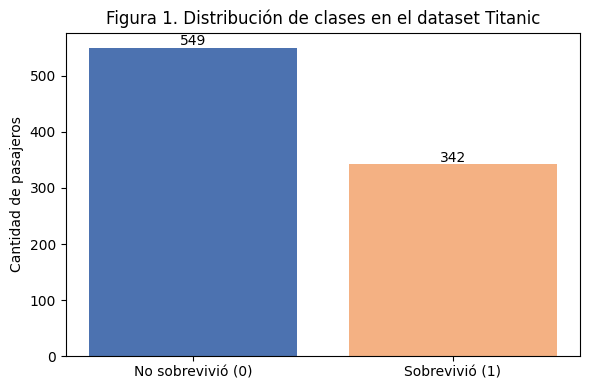

El dataset presenta un desbalance moderado: 61.62% no sobrevivió y 38.38% sobrevivió.


In [4]:
# Figura 1. Distribución de la variable objetivo
conteo = df['survived'].value_counts().sort_index()
proporcion = df['survived'].value_counts(normalize=True).sort_index()
dist_df = pd.DataFrame({
    'Clase': ['No sobrevivió (0)', 'Sobrevivió (1)'],
    'Frecuencia': conteo.values,
    'Proporción': (proporcion.values * 100).round(2)
})
display(dist_df)

plt.figure(figsize=(6, 4))
plt.bar(dist_df['Clase'], dist_df['Frecuencia'], color=['#4C72B0', '#F4B183'])
plt.title('Figura 1. Distribución de clases en el dataset Titanic')
plt.ylabel('Cantidad de pasajeros')
for i, v in enumerate(dist_df['Frecuencia']):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"El dataset presenta un desbalance moderado: {dist_df.loc[0,'Proporción']}% no sobrevivió "
      f"y {dist_df.loc[1,'Proporción']}% sobrevivió.")

## 6. Preparación del proceso de evaluación

Para evitar fuga de información (*data leakage*), el proceso de evaluación sigue este orden:

1. Se separan `X` (predictores) e `y` (`survived`).
2. Se divide el dataset en entrenamiento y prueba (80/20, estratificado).
3. La imputación de `age` y `embarked`, la codificación de variables categóricas y el escalamiento se ajustan **únicamente con el conjunto de entrenamiento**, dentro de un `Pipeline`/`ColumnTransformer`.
4. Esas mismas transformaciones, ya aprendidas, se aplican al conjunto de prueba.

Las tres arquitecturas MLP se evalúan sobre el mismo conjunto de prueba mediante Hold-Out. Adicionalmente, se aplica validación cruzada K-Fold estratificada (k=5) exclusivamente a la red de una capa oculta, ajustando el pipeline completo dentro de cada fold (sin preprocesar antes de generar las particiones).

Las métricas utilizadas son accuracy, precision, recall y F1-score sobre la clase `sobrevivió = 1`, complementadas con la matriz de confusión (TN, FP, FN, TP), que es la evidencia que exige la rúbrica de esta fase.

## 7. Partición entrenamiento/prueba

In [5]:
# Separación de predictores y variable objetivo
X = df.drop(columns='survived')
y = df['survived']

# Partición 80/20 estratificada y reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Observaciones de entrenamiento:', X_train.shape[0])
print('Observaciones de prueba:', X_test.shape[0])
print('\nProporción de clases en entrenamiento:')
print(y_train.value_counts(normalize=True).round(4))
print('\nProporción de clases en prueba:')
print(y_test.value_counts(normalize=True).round(4))

Observaciones de entrenamiento: 712
Observaciones de prueba: 179

Proporción de clases en entrenamiento:
survived
0   0.6166
1   0.3834
Name: proportion, dtype: float64

Proporción de clases en prueba:
survived
0   0.6145
1   0.3855
Name: proportion, dtype: float64


La estratificación (`stratify=y`) mantiene aproximadamente la misma proporción de sobrevivientes (≈38,4%) en ambos conjuntos. Esto es relevante porque el dataset presenta un desbalance moderado entre clases: sin estratificar, una partición aleatoria podría sobre- o subrepresentar la clase positiva en el conjunto de prueba, distorsionando precision y recall sin que ello refleje una diferencia real de desempeño del modelo.

## 8. Pipeline de preprocesamiento

In [6]:
# Variables numéricas y categóricas del conjunto de predictores
columnas_numericas = ['pclass', 'age', 'sibsp', 'parch', 'fare']
columnas_categoricas = ['sex', 'embarked']

# Transformación de variables numéricas: imputación por mediana + escalamiento
transformador_numerico = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

# Transformación de variables categóricas: imputación por moda + codificación one-hot
transformador_categorico = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ColumnTransformer que integra ambas ramas de preprocesamiento
preprocesador = ColumnTransformer([
    ('num', transformador_numerico, columnas_numericas),
    ('cat', transformador_categorico, columnas_categoricas)
])

def construir_pipeline(hidden_layer_sizes):
    """Crea el pipeline completo (preprocesamiento + MLP) para una arquitectura dada."""
    return Pipeline([
        ('preprocesamiento', preprocesador),
        ('mlp', MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu',
                               solver='adam', max_iter=500, random_state=RANDOM_STATE))
    ])

def evaluar_pipeline(pipeline, X_tr, y_tr, X_ev, y_ev):
    """Función común de evaluación: ajusta el pipeline y calcula métricas y matriz de
    confusión sobre la clase positiva (sobrevivió = 1). Se usa tanto en Hold-Out como en
    cada fold del K-Fold, evitando código duplicado."""
    with warnings.catch_warnings(record=True) as registro:
        warnings.simplefilter('always', ConvergenceWarning)
        pipeline.fit(X_tr, y_tr)
        hubo_advertencia_convergencia = any(issubclass(w.category, ConvergenceWarning) for w in registro)

    y_pred = pipeline.predict(X_ev)
    cm = confusion_matrix(y_ev, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metricas = {
        'accuracy': accuracy_score(y_ev, y_pred),
        'precision': precision_score(y_ev, y_pred, pos_label=1, zero_division=0),
        'recall': recall_score(y_ev, y_pred, pos_label=1, zero_division=0),
        'f1': f1_score(y_ev, y_pred, pos_label=1, zero_division=0),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'n_iter': pipeline.named_steps['mlp'].n_iter_,
        'convergence_warning': hubo_advertencia_convergencia
    }
    return metricas, cm, y_pred

print('Pipeline y función común de evaluación definidos correctamente.')

Pipeline y función común de evaluación definidos correctamente.


## 9. Evaluación del MLP de una capa oculta

Arquitectura `(100,)`, activación ReLU, solver Adam, `max_iter=500`, `random_state=42`, evaluada sobre el conjunto de prueba (Hold-Out).

In [7]:
resultados_holdout = {}
matrices_holdout = {}

pipe_mlp1 = construir_pipeline((100,))
res_mlp1, cm_mlp1, pred_mlp1 = evaluar_pipeline(pipe_mlp1, X_train, y_train, X_test, y_test)
resultados_holdout['MLP 1 capa oculta'] = res_mlp1
matrices_holdout['MLP 1 capa oculta'] = cm_mlp1

print('MLP 1 capa oculta —', res_mlp1)
print('Iteraciones utilizadas:', res_mlp1['n_iter'], '| ConvergenceWarning:', res_mlp1['convergence_warning'])
pd.DataFrame(cm_mlp1, index=['Real 0', 'Real 1'], columns=['Pred. 0', 'Pred. 1'])

MLP 1 capa oculta — {'accuracy': 0.7821229050279329, 'precision': 0.7678571428571429, 'recall': 0.6231884057971014, 'f1': 0.688, 'tn': 97, 'fp': 13, 'fn': 26, 'tp': 43, 'n_iter': 500, 'convergence_warning': True}
Iteraciones utilizadas: 500 | ConvergenceWarning: True


,Pred. 0,Pred. 1
Real 0,97,13
Real 1,26,43


**Interpretación — MLP 1 capa oculta:** el modelo alcanza un desempeño global moderado en el conjunto de prueba. La precision sobre la clase sobrevivió indica qué proporción de los pasajeros predichos como sobrevivientes efectivamente lo fueron, mientras que el recall indica qué proporción de los sobrevivientes reales fue detectada por el modelo. El F1-score resume el equilibrio entre ambas. Los falsos negativos corresponden a sobrevivientes reales que el modelo no detecta, y los falsos positivos a pasajeros que el modelo predice como sobrevivientes sin haberlo sido. Su principal fortaleza es la simplicidad de la arquitectura; su principal limitación es que, en esta ejecución, el entrenamiento alcanza el máximo de iteraciones (`max_iter=500`) con `ConvergenceWarning`, lo que se documenta como limitación sin corregirse mediante un ajuste adicional de hiperparámetros.

## 10. Evaluación del MLP de dos capas ocultas

Arquitectura `(100, 50)`, mismos parámetros de activación, solver, iteraciones máximas y semilla, evaluada sobre el mismo conjunto de prueba.

In [8]:
pipe_mlp2 = construir_pipeline((100, 50))
res_mlp2, cm_mlp2, pred_mlp2 = evaluar_pipeline(pipe_mlp2, X_train, y_train, X_test, y_test)
resultados_holdout['MLP 2 capas ocultas'] = res_mlp2
matrices_holdout['MLP 2 capas ocultas'] = cm_mlp2

print('MLP 2 capas ocultas —', res_mlp2)
print('Iteraciones utilizadas:', res_mlp2['n_iter'], '| ConvergenceWarning:', res_mlp2['convergence_warning'])
pd.DataFrame(cm_mlp2, index=['Real 0', 'Real 1'], columns=['Pred. 0', 'Pred. 1'])

MLP 2 capas ocultas — {'accuracy': 0.8156424581005587, 'precision': 0.7903225806451613, 'recall': 0.7101449275362319, 'f1': 0.7480916030534351, 'tn': 97, 'fp': 13, 'fn': 20, 'tp': 49, 'n_iter': 500, 'convergence_warning': True}
Iteraciones utilizadas: 500 | ConvergenceWarning: True


,Pred. 0,Pred. 1
Real 0,97,13
Real 1,20,49


**Interpretación — MLP 2 capas ocultas:** agregar una segunda capa aumenta la capacidad representacional de la red. En esta ejecución el modelo mejora respecto de la arquitectura de una capa en las cuatro métricas, con menos falsos negativos, lo que sugiere una mejor identificación de sobrevivientes reales sin deteriorar la precisión. Su fortaleza principal es ese equilibrio entre precision y recall; su limitación es la mayor complejidad y menor interpretabilidad frente a la red de una capa, además de mantener `ConvergenceWarning` al alcanzar el máximo de iteraciones.

## 11. Evaluación del MLP de tres capas ocultas

Arquitectura `(100, 50, 25)`, mismos parámetros de activación, solver, iteraciones máximas y semilla, evaluada sobre el mismo conjunto de prueba.

In [9]:
pipe_mlp3 = construir_pipeline((100, 50, 25))
res_mlp3, cm_mlp3, pred_mlp3 = evaluar_pipeline(pipe_mlp3, X_train, y_train, X_test, y_test)
resultados_holdout['MLP 3 capas ocultas'] = res_mlp3
matrices_holdout['MLP 3 capas ocultas'] = cm_mlp3

print('MLP 3 capas ocultas —', res_mlp3)
print('Iteraciones utilizadas:', res_mlp3['n_iter'], '| ConvergenceWarning:', res_mlp3['convergence_warning'])
pd.DataFrame(cm_mlp3, index=['Real 0', 'Real 1'], columns=['Pred. 0', 'Pred. 1'])

MLP 3 capas ocultas — {'accuracy': 0.8044692737430168, 'precision': 0.7931034482758621, 'recall': 0.6666666666666666, 'f1': 0.7244094488188977, 'tn': 98, 'fp': 12, 'fn': 23, 'tp': 46, 'n_iter': 313, 'convergence_warning': False}
Iteraciones utilizadas: 313 | ConvergenceWarning: False


,Pred. 0,Pred. 1
Real 0,98,12
Real 1,23,46


**Interpretación — MLP 3 capas ocultas:** la red más profunda obtiene la mayor precision del conjunto, aunque con un recall inferior al de la arquitectura de dos capas, lo que se traduce en más falsos negativos que esa configuración. A diferencia de las dos arquitecturas anteriores, en esta ejecución el entrenamiento converge antes de alcanzar `max_iter=500` (sin `ConvergenceWarning`). Su fortaleza es la mayor precisión sobre la clase positiva; su limitación es la mayor complejidad del modelo y una capacidad algo menor para detectar sobrevivientes reales que la arquitectura de dos capas.

## 12. Tabla comparativa Hold-Out

Se consolidan las métricas de las tres arquitecturas evaluadas sobre el **mismo conjunto de prueba** (protocolo Hold-Out). Esta tabla no incluye el resultado de la validación cruzada, que se presenta por separado en la Sección 14, conforme a lo exigido por la pauta.

,Accuracy,Precision,Recall,F1-score
MLP 1 capa oculta,0.7821,0.7679,0.6232,0.6880
MLP 2 capas ocultas,0.8156,0.7903,0.7101,0.7481
MLP 3 capas ocultas,0.8045,0.7931,0.6667,0.7244


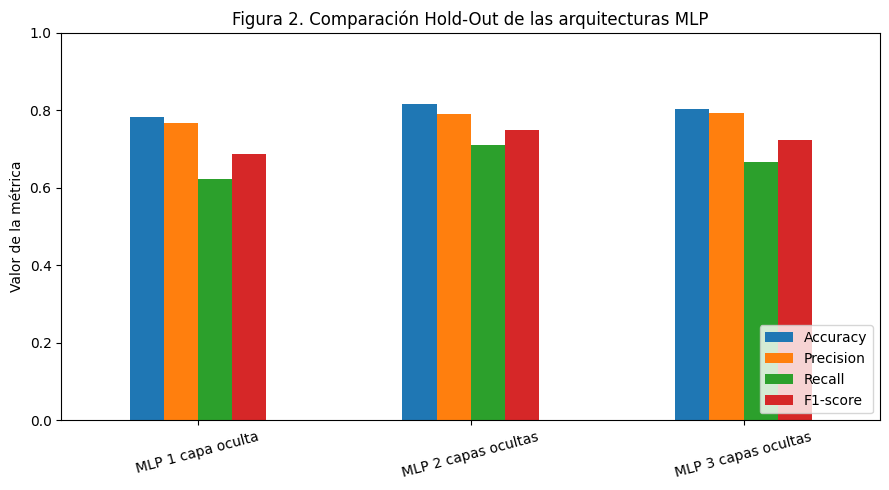

In [10]:
tabla_holdout = pd.DataFrame(resultados_holdout).T[['accuracy', 'precision', 'recall', 'f1']]
tabla_holdout.columns = ['Accuracy', 'Precision', 'Recall', 'F1-score']
tabla_holdout = tabla_holdout.astype(float).round(4)
display(tabla_holdout)

plt.figure(figsize=(9, 5))
tabla_holdout.plot(kind='bar', ax=plt.gca())
plt.title('Figura 2. Comparación Hold-Out de las arquitecturas MLP')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_comparacion_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Matrices de confusión

Matrices de confusión de las tres arquitecturas sobre el conjunto de prueba, con el detalle de TN, FP, FN y TP para cada una.

,TN,FP,FN,TP
MLP 1 capa oculta,97,13,26,43
MLP 2 capas ocultas,97,13,20,49
MLP 3 capas ocultas,98,12,23,46


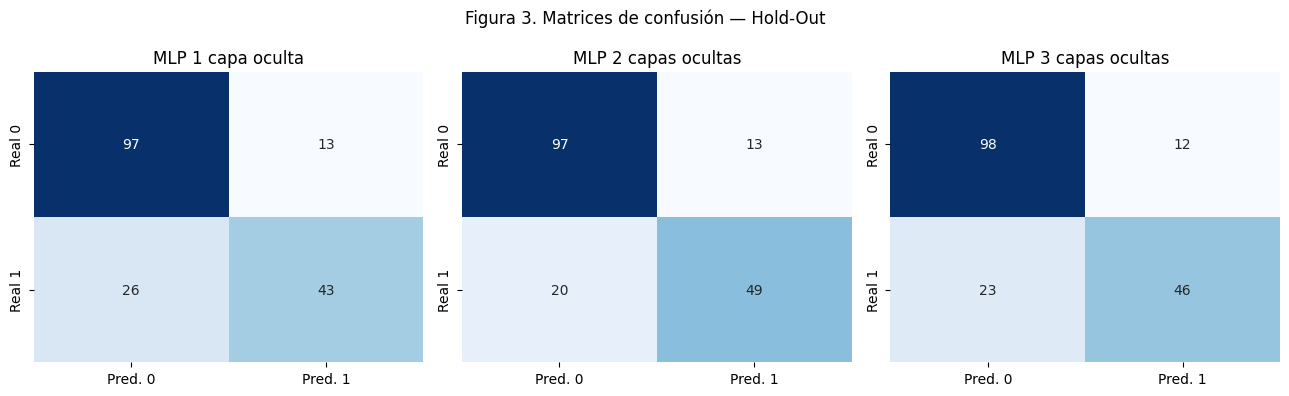

In [11]:
tabla_cm = pd.DataFrame(resultados_holdout).T[['tn', 'fp', 'fn', 'tp']].astype(int)
tabla_cm.columns = ['TN', 'FP', 'FN', 'TP']
display(tabla_cm)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titulos = ['MLP 1 capa oculta', 'MLP 2 capas ocultas', 'MLP 3 capas ocultas']
matrices = [cm_mlp1, cm_mlp2, cm_mlp3]
for ax, cm, titulo in zip(axes, matrices, titulos):
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax, cmap='Blues',
                xticklabels=['Pred. 0', 'Pred. 1'], yticklabels=['Real 0', 'Real 1'])
    ax.set_title(titulo)
plt.suptitle('Figura 3. Matrices de confusión — Hold-Out')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_matrices_confusion_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. K-Fold del MLP de una capa oculta

La pauta exige aplicar validación cruzada únicamente a la red de una capa oculta. Se utiliza **K-Fold estratificado** (`StratifiedKFold`) con 5 particiones, lo que corresponde a una aplicación estratificada de K-Fold: mantiene aproximadamente la misma proporción de clases (`survived`) en cada partición, lo cual es relevante dado el desbalance moderado del dataset (61,6% / 38,4%).

El pipeline completo (imputación, codificación, escalamiento y MLP) se ajusta **dentro de cada fold**, utilizando únicamente los datos de entrenamiento de ese fold; no se realiza ningún preprocesamiento antes de generar las particiones, para evitar fuga de información entre folds.

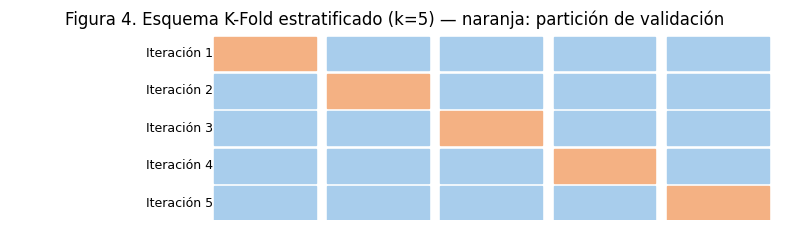

In [12]:
# Figura 4. Esquema conceptual de K-Fold (k=5)
fig, ax = plt.subplots(figsize=(8, 2.4))
n_folds = 5
for i in range(n_folds):
    for j in range(n_folds):
        color = '#F4B183' if j == i else '#A8CDEC'
        ax.add_patch(plt.Rectangle((j, n_folds - i - 1), 0.9, 0.9, color=color))
    ax.text(-0.6, n_folds - i - 0.55, f'Iteración {i+1}', va='center', fontsize=9)
ax.set_xlim(-1.8, n_folds)
ax.set_ylim(0, n_folds)
ax.axis('off')
ax.set_title('Figura 4. Esquema K-Fold estratificado (k=5) — naranja: partición de validación')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_esquema_kfold.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Validación cruzada K-Fold estratificada (k=5) — MLP de una capa oculta
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_rows = []
matrices_cv = []
print('Ejecutando K-Fold estratificado (k=5) sobre el conjunto de entrenamiento...\n')

for fold, (idx_train, idx_val) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr_fold = X_train.iloc[idx_train]
    X_val_fold = X_train.iloc[idx_val]
    y_tr_fold = y_train.iloc[idx_train]
    y_val_fold = y_train.iloc[idx_val]

    # El pipeline se ajusta desde cero en cada fold (sin preprocesar antes de dividir)
    pipe_fold = construir_pipeline((100,))
    metricas_fold, cm_fold, _ = evaluar_pipeline(pipe_fold, X_tr_fold, y_tr_fold, X_val_fold, y_val_fold)
    metricas_fold['fold'] = fold
    fold_rows.append(metricas_fold)
    matrices_cv.append(cm_fold)
    print(f"Fold {fold}: accuracy={metricas_fold['accuracy']:.4f} | precision={metricas_fold['precision']:.4f} | "
          f"recall={metricas_fold['recall']:.4f} | f1={metricas_fold['f1']:.4f} | "
          f"iteraciones={metricas_fold['n_iter']} | ConvergenceWarning={metricas_fold['convergence_warning']}")

Ejecutando K-Fold estratificado (k=5) sobre el conjunto de entrenamiento...



Fold 1: accuracy=0.8601 | precision=0.8571 | recall=0.7636 | f1=0.8077 | iteraciones=500 | ConvergenceWarning=True


Fold 2: accuracy=0.7972 | precision=0.7826 | recall=0.6545 | f1=0.7129 | iteraciones=500 | ConvergenceWarning=True


Fold 3: accuracy=0.8592 | precision=0.9070 | recall=0.7091 | f1=0.7959 | iteraciones=500 | ConvergenceWarning=True


Fold 4: accuracy=0.8099 | precision=0.7368 | recall=0.7778 | f1=0.7568 | iteraciones=500 | ConvergenceWarning=True


Fold 5: accuracy=0.8028 | precision=0.8095 | recall=0.6296 | f1=0.7083 | iteraciones=500 | ConvergenceWarning=True


## 15. Resultados por fold

,Fold,Accuracy,Precision,Recall,F1-score,Iteraciones,ConvergenceWarning
0,1,0.8601,0.8571,0.7636,0.8077,500,True
1,2,0.7972,0.7826,0.6545,0.7129,500,True
2,3,0.8592,0.9070,0.7091,0.7959,500,True
3,4,0.8099,0.7368,0.7778,0.7568,500,True
4,5,0.8028,0.8095,0.6296,0.7083,500,True


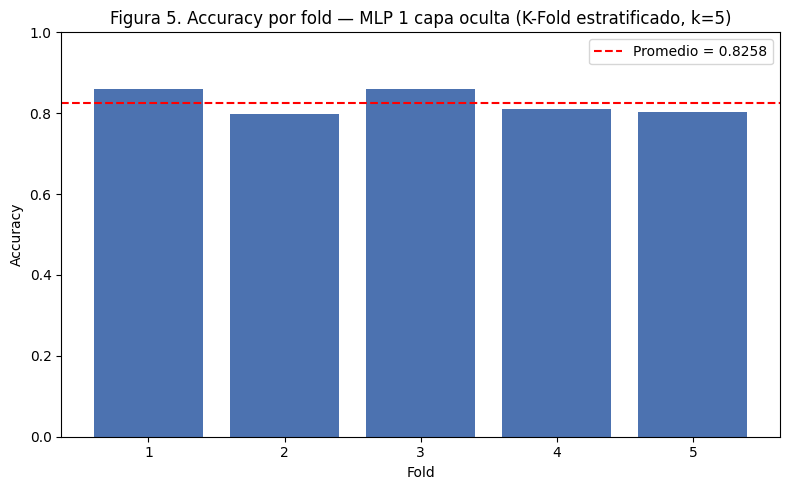

Folds con ConvergenceWarning: 5 de 5


In [14]:
folds_df = pd.DataFrame(fold_rows)[['fold', 'accuracy', 'precision', 'recall', 'f1',
                                     'n_iter', 'convergence_warning']]
folds_df.columns = ['Fold', 'Accuracy', 'Precision', 'Recall', 'F1-score',
                     'Iteraciones', 'ConvergenceWarning']
display(folds_df.round(4))

plt.figure(figsize=(8, 5))
plt.bar(folds_df['Fold'].astype(str), folds_df['Accuracy'], color='#4C72B0')
plt.axhline(folds_df['Accuracy'].mean(), color='red', linestyle='--',
            label=f"Promedio = {folds_df['Accuracy'].mean():.4f}")
plt.title('Figura 5. Accuracy por fold — MLP 1 capa oculta (K-Fold estratificado, k=5)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_accuracy_por_fold.png', dpi=150, bbox_inches='tight')
plt.show()

n_folds_convergencia = int(folds_df['ConvergenceWarning'].sum())
print(f"Folds con ConvergenceWarning: {n_folds_convergencia} de {len(folds_df)}")

## 16. Promedio y desviación estándar

In [15]:
resumen_cv = folds_df[['Accuracy', 'Precision', 'Recall', 'F1-score']].agg(['mean', 'std'])
resumen_cv.index = ['Promedio', 'Desviación estándar']
display(resumen_cv.round(4))

# Matriz de confusión agregada de las 5 particiones de validación (evidencia complementaria)
cm_cv_agregada = sum(matrices_cv)
display(pd.DataFrame(cm_cv_agregada, index=['Real 0', 'Real 1'], columns=['Pred. 0', 'Pred. 1']))

,Accuracy,Precision,Recall,F1-score
Promedio,0.8258,0.8186,0.7069,0.7563
Desviación estándar,0.0312,0.0659,0.0651,0.0458


,Pred. 0,Pred. 1
Real 0,395,44
Real 1,80,193


In [16]:
# Falsos negativos agregados de la validación cruzada (a partir de la matriz obtenida arriba)
fn_cv = int(cm_cv_agregada[1, 0])
positivos_reales_cv = int(cm_cv_agregada[1, :].sum())
tasa_fn_cv = fn_cv / positivos_reales_cv

print('Falsos negativos (FN):', fn_cv)
print('Positivos reales (sobrevivió = 1):', positivos_reales_cv)
print(f'Proporción de positivos reales no detectados: {tasa_fn_cv:.2%}')

Falsos negativos (FN): 80
Positivos reales (sobrevivió = 1): 273
Proporción de positivos reales no detectados: 29.30%


La matriz agregada muestra qué proporción de sobrevivientes reales no fue detectada en las cinco particiones. Este resultado complementa el recall promedio y permite dimensionar los falsos negativos del modelo.

**Interpretación de la variabilidad:** la desviación estándar del accuracy entre folds es reducida en comparación con el rango observado en las métricas de precision y recall, lo que indica que el desempeño global del MLP de una capa oculta se mantiene relativamente estable ante distintas particiones del conjunto de entrenamiento. La mayor dispersión se concentra en precision y recall, lo cual es esperable dado el tamaño moderado de cada fold de validación y el desbalance de clases: con menos observaciones de la clase positiva por fold, unos pocos casos mal clasificados modifican proporcionalmente más estas métricas que el accuracy. Esto no invalida la estabilidad general del modelo, pero sí matiza su lectura: el promedio de precision y recall debe interpretarse junto con su variabilidad, no solo como un valor puntual.
 Los cinco folds registraron `ConvergenceWarning` al alcanzar `max_iter=500`, por lo que estos resultados de K-Fold deben considerarse preliminares: el optimizador no completó su convergencia natural en ninguna de las cinco particiones, lo que limita la interpretación de la estabilidad estimada.

## 17. Interpretación comparativa

Hold-Out (Sección 12) y K-Fold (Secciones 14-16) son protocolos distintos y sus resultados no son directamente equivalentes: el Hold-Out evalúa una única partición fija de prueba, mientras que el K-Fold promedia el desempeño en cinco particiones internas del conjunto de entrenamiento. Por esta razón, la pauta indica presentarlos por separado y no incorporar el promedio del K-Fold como una cuarta arquitectura dentro del ranking Hold-Out.

Comparando ambos resultados para el MLP de una capa oculta, el accuracy promedio obtenido en K-Fold (0,8258) difiere del accuracy puntual obtenido en Hold-Out (0,7821). Esta diferencia no debe leerse como que K-Fold produce naturalmente un mejor desempeño: son protocolos distintos, aplicados sobre particiones distintas (una partición de prueba fija frente a cinco particiones internas del conjunto de entrenamiento), por lo que el promedio K-Fold no representa una mejora del modelo respecto del resultado Hold-Out. La diferencia observada puede estar asociada a la composición particular de las muestras de validación de cada protocolo, y por ello ambos resultados se reportan por separado y no se incorporan en un mismo ranking.

Entre las tres arquitecturas evaluadas mediante Hold-Out, el MLP de dos capas ocultas presenta el mejor desempeño conjunto, al obtener el mayor accuracy, recall y F1-score. El MLP de tres capas alcanza una precision levemente superior, pero presenta un recall menor, asociado a una mayor cantidad de falsos negativos. Por tanto, el MLP de dos capas constituye el candidato preliminar con mejor equilibrio de métricas en esta partición, sin que ello represente una selección definitiva.

## 18. Fortalezas y limitaciones

| Arquitectura | Fortaleza | Limitación |
|---|---|---|
| MLP 1 capa (100,) | Arquitectura más simple; única evaluada también mediante K-Fold, lo que permite estimar su estabilidad | Menor accuracy, recall y F1-score que las otras dos arquitecturas en el conjunto de prueba; alcanza `max_iter=500` con `ConvergenceWarning` |
| MLP 2 capas (100,50) | Mejor equilibrio entre precision y recall; mayor F1-score del conjunto Hold-Out | Mayor complejidad que la red de una capa; también alcanza `max_iter=500` con `ConvergenceWarning` |
| MLP 3 capas (100,50,25) | Mayor precision sobre la clase sobrevivió; converge antes de `max_iter=500` | Recall inferior al del MLP de dos capas (más falsos negativos); mayor complejidad y menor interpretabilidad |

De forma transversal, las tres arquitecturas comparten la limitación de haberse entrenado y evaluado sobre un único dataset (Titanic) y una única partición de prueba para el caso Hold-Out, por lo que sus resultados no deben generalizarse a otros contextos de datos.

## Justificación metodológica de la validación utilizada

Accuracy, precision, recall y F1-score son pertinentes porque el problema es de clasificación binaria con clases moderadamente desbalanceadas; el accuracy resume el acierto global, mientras que precision y recall, calculados sobre la clase positiva **sobrevivió = 1**, muestran respectivamente qué tan confiables son las predicciones positivas y qué proporción de sobrevivientes reales detecta el modelo, y el F1-score equilibra ambas lecturas en un solo valor.

La elección de K-Fold con cinco particiones responde al tamaño moderado del conjunto de entrenamiento, compuesto por 712 observaciones. Hold-Out presenta un costo computacional menor, pero su estimación depende de una sola partición. K-Fold requiere entrenar la red cinco veces y permite calcular el desempeño promedio y su variabilidad. Leave-One-Out requeriría aproximadamente 712 entrenamientos sobre este conjunto, lo que supone un costo considerablemente mayor para una red neuronal sin una ventaja proporcional para el objetivo de este avance. Por ello, cinco folds ofrecen un compromiso razonable entre costo computacional y estabilidad esperada de las métricas.

## 19. Conclusiones preliminares

1. Entre las tres arquitecturas evaluadas mediante Hold-Out, el **MLP de dos capas ocultas** es el candidato preliminar con mejor equilibrio de métricas, al obtener el mayor accuracy, recall y F1-score. El **MLP de tres capas ocultas** presenta la mayor precision, aunque con un recall menor asociado a más falsos negativos.
2. El **MLP de una capa oculta** es el modelo validado mediante K-Fold estratificado (k=5) por exigencia de la pauta. Su validación cruzada muestra una estabilidad razonable en accuracy (desviación estándar de 0,0312), con variabilidad algo mayor en precision (0,0659) y recall (0,0651) entre folds.
3. Las advertencias de convergencia (`ConvergenceWarning`) registradas en el MLP de una y dos capas, y en los cinco folds de la validación cruzada, limitan la interpretación de estos resultados: el optimizador no completó su convergencia natural bajo `max_iter=500`, por lo que las cifras de K-Fold se consideran preliminares.
4. El uso de `Pipeline`/`ColumnTransformer`, partición estratificada y ajuste del preprocesamiento solo con datos de entrenamiento evita la fuga de información observada en versiones previas del análisis, por lo que las cifras de este notebook constituyen la referencia válida para el informe de la Fase 4.
5. No se selecciona definitivamente un modelo final en esta fase: la elección entre las tres arquitecturas para etapas posteriores del proyecto debe considerar conjuntamente las cuatro métricas, la estabilidad observada y la complejidad de cada red, y no basarse únicamente en el accuracy ni en una sola partición Hold-Out.